# Baseline Code

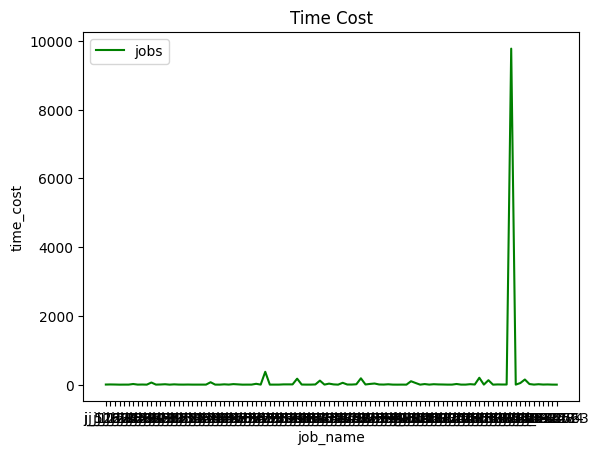

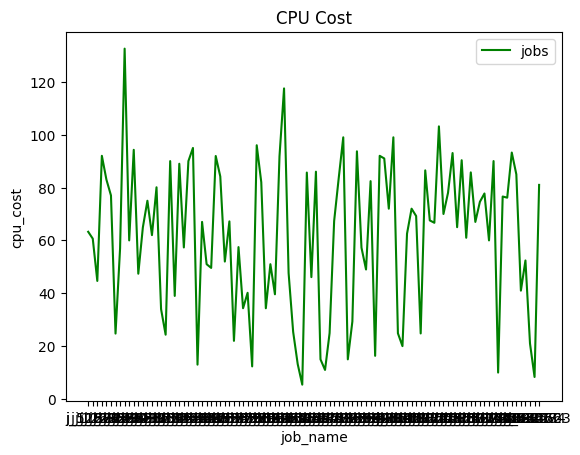

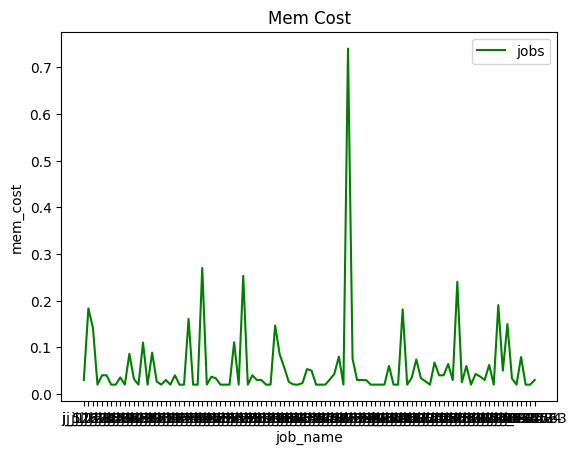

In [1]:
import pandas as pd

from models.autoscaler.baseline import Baseline
from models.utils.dataset import *
from models.utils.figure import LineChart

df_batch_task = pd.read_csv(para.get("selected_batch_task_path"))
df_batch_instance = pd.read_csv(para.get("selected_batch_instance_path"))

# 时间和空间成本对比
df_batch_instance_rows = df_batch_instance.shape[0]
i = 0
x_data, y1_data, y2_data, y3_data = [], [], [], []
while i < df_batch_instance_rows:
    instance_nums = 0
    job_name = df_batch_instance.loc[i, 'job_name']
    while (i + instance_nums < df_batch_instance_rows) and (
            df_batch_instance.loc[i + instance_nums, 'job_name'] == job_name):
        instance_nums += 1
    job = df_batch_instance.loc[i: i + instance_nums - 1].copy()

    # =============== 对每个 job: Baseline 测试 ===============
    x_data.append(job_name)  # 添加 x 轴数据

    baseline = Baseline(job, i)

    time_cost = baseline.get_time_cost()
    y1_data.append(time_cost)  # 添加 y 轴数据

    cpu_cost = baseline.get_cpu_cost()
    y2_data.append(cpu_cost)  # 添加 y 轴数据

    mem_cost = baseline.get_mem_cost()
    y3_data.append(mem_cost)  # 添加 y 轴数据
    # =============== Baseline 测试 : 结束 ===============

    i += instance_nums

# 开始绘图
line_chart = LineChart(x_data, y1_data, title="Time Cost", label="jobs", x_label="job_name", y_label="time_cost")
line_chart.show()

line_chart = LineChart(x_data, y2_data, title="CPU Cost", label="jobs", x_label="job_name", y_label="cpu_cost")
line_chart.show()

line_chart = LineChart(x_data, y3_data, title="Mem Cost", label="jobs", x_label="job_name", y_label="mem_cost")
line_chart.show()

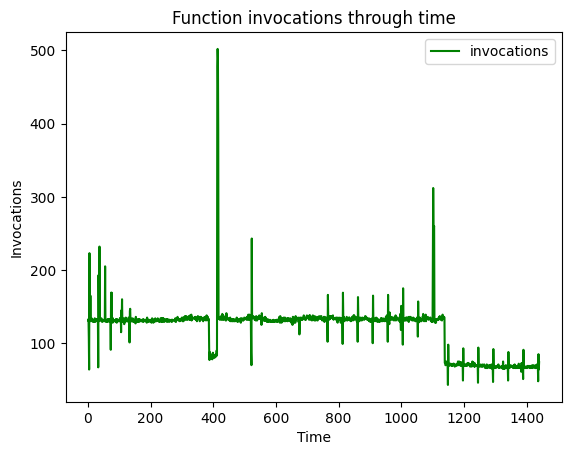

In [2]:
from models.utils.figure import *
import pandas as pd

df = pd.read_csv("../dataset/azure_trace_data_2019/invocations_per_function_md.anon.d01.csv")
data = df.loc[383][4:]
idx = 1
x_data, y_data = [], []
for item in data:
    y_data.append(item)
    x_data.append(idx)
    idx += 1
line_chart = LineChart(x_data, y_data, title="Function invocations through time", label="invocations", x_label="Time", y_label="Invocations")
line_chart.show()

# LSTM Code

In [3]:
from models.autoscaler.lstm import LSTM

lstm = LSTM(num_classes=2, input_size=2, hidden_size=2, num_layers=1, seq_length=4)
lstm.predict()

ModuleNotFoundError: No module named 'torch'

# ARIMA Code

In [ ]:
from models.autoscaler.arima import *

p, d, q = 2, 1, 1
params = [p, d, q]
future_periods = 12

arima = MyARIMA(params, future_periods)
arima.predict()